<div style="text-align: center;">

# Standard Augmentation for Synthetic Data Generation

</div>

**Author**: Dr. Amir Omidvarnia  
**Email**: a.omidvarnia@fz-juelich.de  
**Affiliation**: Forschungszentrum Jülich, Germany  
**Event**: DPG2026 AKPIK tutorial on ML-based image processing for electrochemical applications (7 March 2026)

---

## Overview

A key challenge in supervised ML-based segmentation of electrochemical images is the scarcity of labeled data. Standard **geometric and photometric augmentation** is the simplest and most widely used strategy to expand a small labeled dataset into a larger, more diverse synthetic training set — without learning a generative model.

This notebook demonstrates how to apply configurable augmentation (rotation, scaling, shearing, flipping, and intensity perturbations) to a set of real SEM frames and their corresponding binary masks, generating a synthetic dataset where each transformed image–mask pair remains perfectly annotated by construction.

### Why augmentation works

- **Label preservation**: geometric transformations applied identically to the image and its mask maintain pixel-level correspondence.
- **Invariance induction**: exposing a segmentation model to augmented variants encourages it to learn features that are invariant to typical imaging variations (viewing angle, illumination, magnification).
- **Low cost**: no training of a generative model is required; augmented samples are generated on the fly or pre-computed.

### Relationship to other synthesis methods

This notebook is the simplest of four synthetic data approaches covered in this tutorial:

| Method | Complexity | Requires real data | Labels |
|--------|------------|-------------------|--------|
| **Standard Augmentation (this notebook)** | Low | Yes | Preserved from real |
| Physics-Based (PB) | Medium | No | Analytically derived |
| DCGAN | High | Yes | GAN-derived |
| Stable Diffusion | Very High | Optional | Diffusion-derived |

### Repository and Environment Setup

This section ensures that the analysis is tightly coupled to the local DPG2026 repository so that all subsequent augmentation experiments use an explicitly defined code base and configuration, which is essential for reproducible synthetic data generation studies.


In [5]:
# Add repo root to sys.path so `import src` resolves to the local 'modules/' package
from pathlib import Path
import sys

try:
    notebook_dir = Path(__file__).resolve().parent
except Exception:
    notebook_dir = Path.cwd()

cur = notebook_dir
repo_root = None
for _ in range(6):
    if (cur / 'src').exists():
        repo_root = cur
        break
    if cur.parent == cur:
        break
    cur = cur.parent

if repo_root is None:
    repo_root = Path.cwd()

modules_dir = repo_root / 'src'
repo_root_str = str(repo_root)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)
print(f'Added repo root to sys.path: {repo_root_str} (src dir: {modules_dir})')

Added repo root to sys.path: /Users/amir/GIT_repositories/DPG2026_release (modules dir: /Users/amir/GIT_repositories/DPG2026_release/modules)


### Scientific Tooling Overview
This section assembles numerical, imaging, and logging libraries together with the DPG2026 synthesis and preparation modules, defining the basic computational tools used throughout the notebook.
By importing the synthetic data generator and configuration managers at this stage, we conceptually separate the *model of augmentation* from the *experimental protocol*, which makes it easier to analyse how different augmentation strategies affect downstream segmentation performance.

In [6]:
# Import necessary modules
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)


from src.synth_data_module import SynthDataGenerator
from src.synth_data_module import ConfigLoader
from src.synth_data_module import PreparationManager

### Augmentation Configuration
This step loads the YAML configuration that encodes the statistical model of the augmentation process, including image size, rotation, scaling, shearing ranges and the number of synthetic variants per real frame.
By treating these parameters as part of an explicit experimental design, we can systematically study how the induced distribution of geometric transformations shapes the diversity of synthetic electron microscopy images and the robustness of subsequent segmentation models.

In [ ]:
config_path = repo_root / 'tutorial_parameters.yaml'

config = ConfigLoader(config_path)
logging.info(f"Configuration loaded from: {config_path}")
# Specify dataset and device
dataset = 'dataset_PB'
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
logging.info(f"Using device: {device}.")
method_name = 'Aug'
# Display augmentation parameters
aug_params = config.get_gen_method_params(method_name)
logging.info("Augmentation Parameters:")
logging.info(f"  Image size: {aug_params['width']}x{aug_params['height']}")
logging.info(f"  Rotation range: [{aug_params['min_rotation']}°, {aug_params['max_rotation']}°]")
logging.info(f"  Scale range: [{aug_params['min_scale']}, {aug_params['max_scale']}]")
logging.info(f"  Shear range: [{aug_params['min_shear']}°, {aug_params['max_shear']}°]")
logging.info(f"  Repeats per image: {aug_params['num_repeats_per_image']}")

2026-02-25 15:27:09 - INFO - Configuration loaded from: /Users/amir/GIT_repositories/DPG2026_release/tutorial_parameters.yaml
2026-02-25 15:27:09 - INFO - Using device: cpu.
2026-02-25 15:27:09 - INFO - Augmentation Parameters:
2026-02-25 15:27:09 - INFO -   Image size: 320x320
2026-02-25 15:27:09 - INFO -   Rotation range: [-40°, 40°]
2026-02-25 15:27:09 - INFO -   Scale range: [0.8, 1.5]
2026-02-25 15:27:09 - INFO -   Shear range: [-20°, 20°]
2026-02-25 15:27:09 - INFO -   Repeats per image: 2


### Data Preparation and Generator Initialization
Here we instantiate the preparation and generation components that connect the abstract augmentation parameters to concrete data on disk, including directories for real images, masks, and synthetic outputs.
By limiting the number of real frames used and routing them through a dedicated generator object, we conceptually frame the augmentation pipeline as a controlled experiment on a well-defined subset of the available electron microscopy data.

In [8]:
# Initialize PreparationManager
# Ensure required top-level config keys exist (provide sensible defaults if missing)
cfg_dict = getattr(config, 'config', None)
if cfg_dict is None:
    raise RuntimeError('ConfigLoader did not load a configuration dictionary.')
import os
if 'synth_models_dir' not in cfg_dict:
    cfg_dict['synth_models_dir'] = os.path.join(cfg_dict.get('models_dir', os.getcwd()), 'synth_models')
if 'segmentation_models_dir' not in cfg_dict:
    cfg_dict['segmentation_models_dir'] = os.path.join(cfg_dict.get('models_dir', os.getcwd()), 'segmentation_models')
# Re-wrap config back into ConfigLoader if necessary (ConfigLoader keeps reference to cfg_dict)
prep_manager_aug = PreparationManager(config, dataset, method_name)

# Use only 5 real EM frames for creating synthetic images (demonstration only)
N_images = 5
generator_aug = SynthDataGenerator(
    prep_manager=prep_manager_aug,
    config=config,
    method_name=method_name,
    N_images=N_images,
    device=device
)

### Synthetic Image Generation
This section triggers the standard augmentation pipeline, in which each selected real electron microscopy frame is transformed according to the configured rotation, scaling and shearing distributions to create physically plausible variants.
Conceptually, this step maps a finite set of experimental observations onto a richer synthetic ensemble, approximating a broader range of imaging conditions while preserving the underlying electrochemical microstructure.

In [9]:
print(f"\nGenerating synthetic images using {method_name}...")
generator_aug.generate()
print("Generation complete!")

2026-02-25 15:27:09 - INFO - Parameters for the model were set.
2026-02-25 15:27:09 - INFO - Preprocessing training images...



Generating synthetic images using Aug...


Preprocessing images: 100%|██████████| 5/5 [00:00<00:00, 45.08it/s]
2026-02-25 15:27:09 - INFO - Training images and masks were preprocessed.
2026-02-25 15:27:09 - INFO - Test images and masks were preprocessed.
2026-02-25 15:27:09 - INFO - *******************


Preprocessing complete.
Images saved to: /Users/amir/Documents/DPG2026_Tutorial/preprocessed_data/Aug_dataset_PB/input_images
Masks saved to: /Users/amir/Documents/DPG2026_Tutorial/preprocessed_data/Aug_dataset_PB/input_masks


Generating synthetic images: 100%|██████████| 5/5 [00:08<00:00,  1.67s/it]
2026-02-25 15:27:17 - INFO - Synthetic image and masks were generated and saved.


Generation complete!


### Visual Quality Assessment
This section performs a qualitative inspection of the generated synthetic images and their corresponding binary masks to verify that structural features are preserved under augmentation.
By arranging images and masks in a grid, we can visually assess whether the geometric transformations and inpainting operations produce realistic textures and consistent object boundaries, which is critical for training reliable segmentation models.

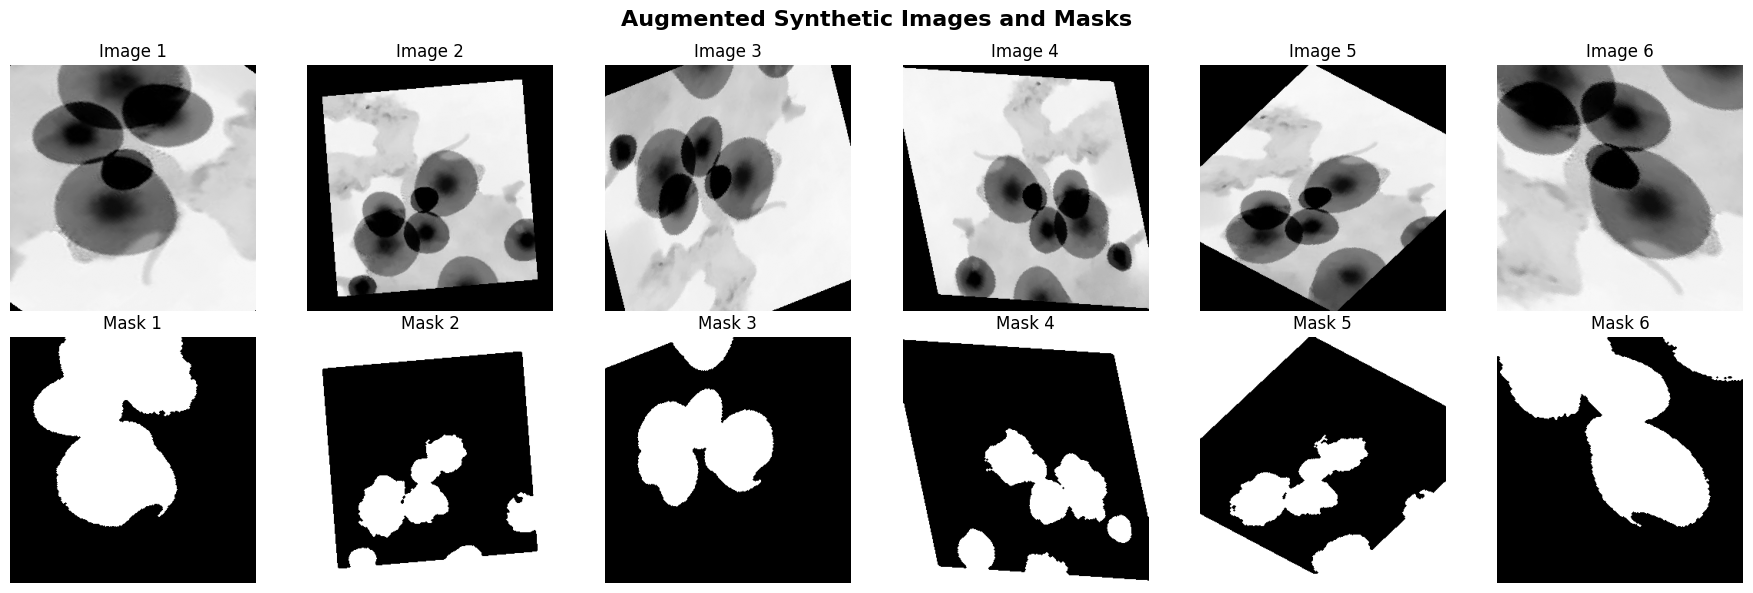

\nDisplayed 6 synthetic images
Total images generated: 10


In [10]:
# Get paths to output directories
output_images_dir = prep_manager_aug.output_images_dir
output_masks_dir = prep_manager_aug.output_bin_masks_dir

# Load generated images
image_files = sorted([f for f in os.listdir(output_images_dir) if f.endswith(('.png', '.jpg'))])[:6]

# Create visualization
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Augmented Synthetic Images and Masks', fontsize=16, fontweight='bold')

for idx, img_file in enumerate(image_files):
    # Load image and mask
    img_path = os.path.join(output_images_dir, img_file)
    mask_path = os.path.join(output_masks_dir, img_file)
    
    img = Image.open(img_path)
    mask = Image.open(mask_path)
    
    # Display image
    axes[0, idx].imshow(img, cmap='gray')
    axes[0, idx].set_title(f'Image {idx+1}')
    axes[0, idx].axis('off')
    
    # Display mask
    axes[1, idx].imshow(mask, cmap='gray')
    axes[1, idx].set_title(f'Mask {idx+1}')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\\nDisplayed {len(image_files)} synthetic images")
print(f"Total images generated: {len(os.listdir(output_images_dir))}")

### Original–Augmented Comparison
Here we compare one representative original electron microscopy image with a small selection of its augmented counterparts to interpret the geometric and photometric changes introduced by the augmentation process.
This side-by-side visualization clarifies which aspects of the microstructure are preserved (for example particle morphology and interfaces) and which are deliberately perturbed, providing intuition about the invariances that the downstream learning algorithms are encouraged to acquire.

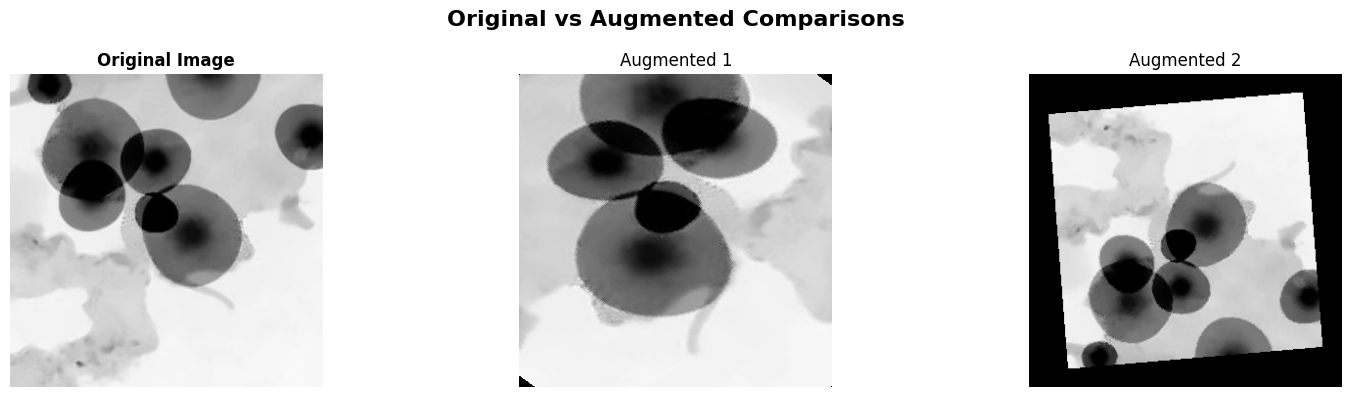

In [11]:
# Load preprocessed input images
input_images_dir = prep_manager_aug.input_images_preprocessed_dir
input_files = sorted([f for f in os.listdir(input_images_dir) if f.endswith(('.png', '.jpg'))])

if input_files:
    # Load original image
    original_img_path = os.path.join(input_images_dir, input_files[0])
    original_img = Image.open(original_img_path)
    
    # Find augmented versions
    base_name = os.path.splitext(input_files[0])[0]
    augmented_files = [f for f in image_files if base_name in f][:2]
    
    # Create comparison plot
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle('Original vs Augmented Comparisons', fontsize=16, fontweight='bold')
    
    # Show original
    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title('Original Image', fontweight='bold')
    axes[0].axis('off')
    
    # Show augmented versions
    for idx, aug_file in enumerate(augmented_files):
        aug_img_path = os.path.join(output_images_dir, aug_file)
        aug_img = Image.open(aug_img_path)
        axes[idx+1].imshow(aug_img, cmap='gray')
        axes[idx+1].set_title(f'Augmented {idx+1}')
        axes[idx+1].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No input images found for comparison")